# Outcomes and Reward Function Analysis
## Goal: Understand patient outcomes to design reward signals for RL

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Data

In [2]:
data_dir = Path('../artifacts/cleaned')

patients = pd.read_parquet(data_dir / 'PATIENTS.parquet')
admissions = pd.read_parquet(data_dir / 'ADMISSIONS.parquet')
icustays = pd.read_parquet(data_dir / 'ICUSTAYS.parquet')

# Convert timestamps
patients['dob'] = pd.to_datetime(patients['dob'])
patients['dod'] = pd.to_datetime(patients['dod'])
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
admissions['deathtime'] = pd.to_datetime(admissions['deathtime'])
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])

print("Data loaded successfully")

Data loaded successfully


## 2. Merge Episode Data with Outcomes

In [3]:
# Merge ICU stays with admissions and patients
episodes = icustays.merge(
    admissions[['hadm_id', 'subject_id', 'hospital_expire_flag', 'deathtime', 'dischtime', 'admittime']], 
    on=['hadm_id', 'subject_id'], 
    how='left'
)

episodes = episodes.merge(
    patients[['subject_id', 'dod', 'gender', 'dob']], 
    on='subject_id', 
    how='left'
)

print(f"Total episodes: {len(episodes)}")
print(f"\nColumn names:")
print(list(episodes.columns))

Total episodes: 136

Column names:
['row_id', 'subject_id', 'hadm_id', 'icustay_id', 'dbsource', 'first_careunit', 'last_careunit', 'first_wardid', 'last_wardid', 'intime', 'outtime', 'los', 'hospital_expire_flag', 'deathtime', 'dischtime', 'admittime', 'dod', 'gender', 'dob']


## 3. Mortality Analysis

In [4]:
# Hospital mortality
hospital_mortality = episodes['hospital_expire_flag'].mean()
num_deaths = episodes['hospital_expire_flag'].sum()

print("="*60)
print("MORTALITY STATISTICS")
print("="*60)
print(f"\nHospital mortality rate: {hospital_mortality:.2%}")
print(f"Deaths: {num_deaths} / {len(episodes)}")

# ICU mortality (died during or shortly after ICU stay)
episodes['icu_mortality'] = (
    episodes['hospital_expire_flag'] == 1
) & (
    episodes['deathtime'].notna()
) & (
    episodes['deathtime'] <= episodes['outtime'] + pd.Timedelta(days=1)
)

icu_mortality = episodes['icu_mortality'].mean()
print(f"\nICU mortality rate: {icu_mortality:.2%}")
print(f"ICU deaths: {episodes['icu_mortality'].sum()}")

MORTALITY STATISTICS

Hospital mortality rate: 33.82%
Deaths: 46 / 136

ICU mortality rate: 26.47%
ICU deaths: 36


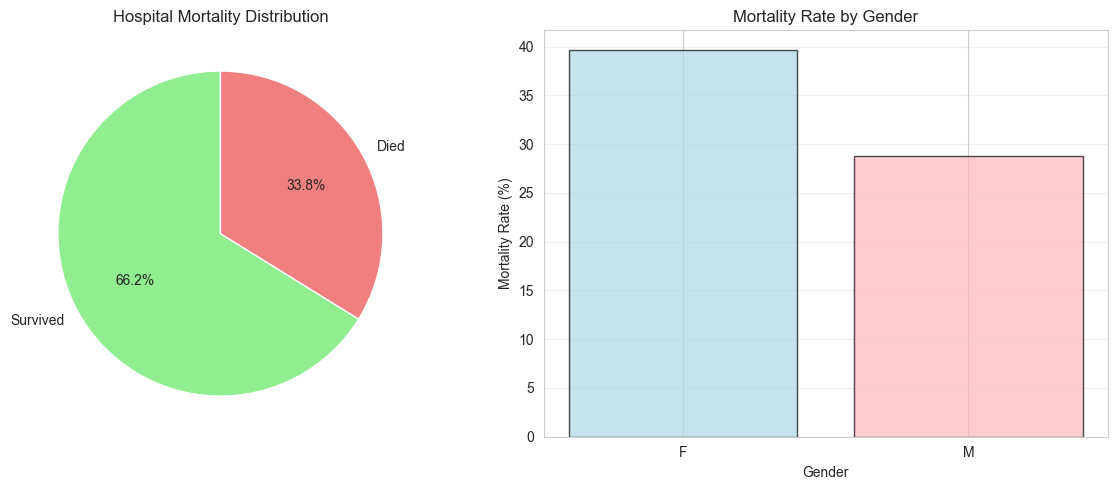

In [5]:
# Visualize mortality
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
mortality_counts = episodes['hospital_expire_flag'].value_counts()
axes[0].pie(mortality_counts, labels=['Survived', 'Died'], autopct='%1.1f%%', 
            colors=['lightgreen', 'lightcoral'], startangle=90)
axes[0].set_title('Hospital Mortality Distribution')

# Bar chart by gender
mortality_by_gender = episodes.groupby('gender')['hospital_expire_flag'].agg(['sum', 'count', 'mean'])
mortality_by_gender['rate'] = mortality_by_gender['mean'] * 100
axes[1].bar(mortality_by_gender.index, mortality_by_gender['rate'], 
            edgecolor='black', alpha=0.7, color=['lightblue', 'lightpink'])
axes[1].set_ylabel('Mortality Rate (%)')
axes[1].set_xlabel('Gender')
axes[1].set_title('Mortality Rate by Gender')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Length of Stay Analysis

In [6]:
# Compare LOS between survivors and non-survivors
survivors_los = episodes[episodes['hospital_expire_flag'] == 0]['los']
non_survivors_los = episodes[episodes['hospital_expire_flag'] == 1]['los']

print("\nICU Length of Stay by Outcome:")
print("\nSurvivors:")
print(survivors_los.describe())
print("\nNon-survivors:")
print(non_survivors_los.describe())


ICU Length of Stay by Outcome:

Survivors:
count    90.000000
mean      3.820207
std       5.234692
min       0.654900
25%       1.265550
50%       2.004700
75%       3.706125
max      31.123500
Name: los, dtype: float64

Non-survivors:
count    46.000000
mean      5.689467
std       7.657891
min       0.105900
25%       1.060075
50%       2.558750
75%       6.907075
max      35.406500
Name: los, dtype: float64


C:\Users\mezzine\AppData\Local\Temp\ipykernel_22264\1804536616.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(los_by_outcome, labels=['Survived', 'Died'], patch_artist=True,


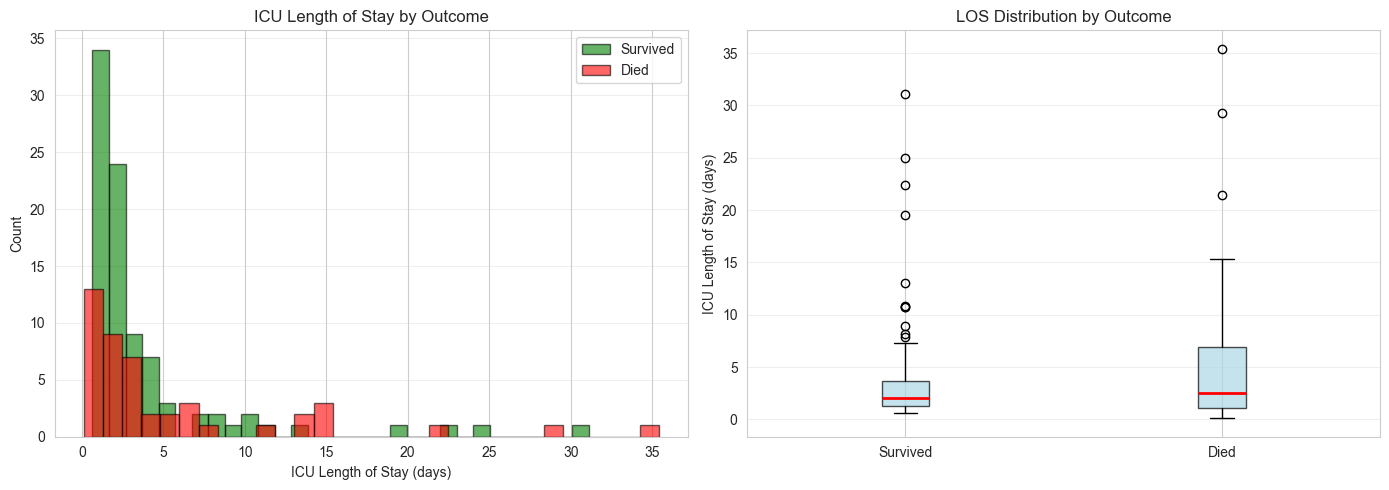

In [7]:
# Visualize LOS distribution by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(survivors_los, bins=30, alpha=0.6, label='Survived', edgecolor='black', color='green')
axes[0].hist(non_survivors_los, bins=30, alpha=0.6, label='Died', edgecolor='black', color='red')
axes[0].set_xlabel('ICU Length of Stay (days)')
axes[0].set_ylabel('Count')
axes[0].set_title('ICU Length of Stay by Outcome')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot
los_by_outcome = [survivors_los, non_survivors_los]
axes[1].boxplot(los_by_outcome, labels=['Survived', 'Died'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('ICU Length of Stay (days)')
axes[1].set_title('LOS Distribution by Outcome')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Time to Death Analysis (for survivors who died)

In [8]:
# For patients who died, calculate time from ICU admission to death
died_patients = episodes[episodes['deathtime'].notna()].copy()
died_patients['hours_to_death'] = (
    died_patients['deathtime'] - died_patients['intime']
).dt.total_seconds() / 3600

print(f"\nPatients with recorded death time: {len(died_patients)}")
print("\nTime from ICU admission to death (hours):")
print(died_patients['hours_to_death'].describe())

# Convert to days
print("\nTime from ICU admission to death (days):")
print((died_patients['hours_to_death'] / 24).describe())


Patients with recorded death time: 46

Time from ICU admission to death (hours):
count     46.000000
mean     183.396159
std      220.224562
min        0.896944
25%       27.332986
50%      100.484583
75%      241.472778
max      835.783333
Name: hours_to_death, dtype: float64

Time from ICU admission to death (days):
count    46.000000
mean      7.641507
std       9.176023
min       0.037373
25%       1.138874
50%       4.186858
75%      10.061366
max      34.824306
Name: hours_to_death, dtype: float64


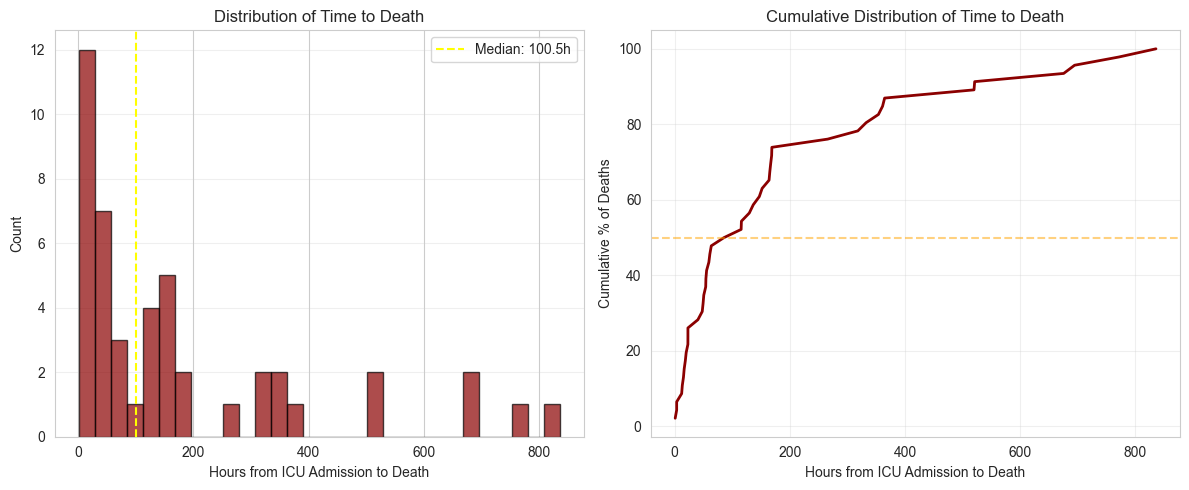

In [9]:
# Visualize time to death
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(died_patients['hours_to_death'], bins=30, edgecolor='black', alpha=0.7, color='darkred')
plt.xlabel('Hours from ICU Admission to Death')
plt.ylabel('Count')
plt.title('Distribution of Time to Death')
plt.axvline(died_patients['hours_to_death'].median(), color='yellow', 
            linestyle='--', label=f'Median: {died_patients["hours_to_death"].median():.1f}h')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
# Cumulative distribution
sorted_hours = np.sort(died_patients['hours_to_death'].dropna())
cumulative = np.arange(1, len(sorted_hours) + 1) / len(sorted_hours) * 100
plt.plot(sorted_hours, cumulative, linewidth=2, color='darkred')
plt.xlabel('Hours from ICU Admission to Death')
plt.ylabel('Cumulative % of Deaths')
plt.title('Cumulative Distribution of Time to Death')
plt.axhline(50, color='orange', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Clinical Improvement Proxy (LOS Change)

In [10]:
# Shorter LOS could indicate faster recovery (if survived)
# Longer LOS could indicate complications

# Categorize LOS
episodes['los_category'] = pd.cut(
    episodes['los'], 
    bins=[0, 1, 3, 7, 14, 1000], 
    labels=['<1 day', '1-3 days', '3-7 days', '7-14 days', '>14 days']
)

# Mortality by LOS category
mortality_by_los = episodes.groupby('los_category')['hospital_expire_flag'].agg(['sum', 'count', 'mean'])
mortality_by_los['rate'] = mortality_by_los['mean'] * 100

print("\nMortality Rate by Length of Stay Category:")
print(mortality_by_los)


Mortality Rate by Length of Stay Category:
              sum  count      mean       rate
los_category                                 
<1 day         10     22  0.454545  45.454545
1-3 days       18     69  0.260870  26.086957
3-7 days        6     20  0.300000  30.000000
7-14 days       6     15  0.400000  40.000000
>14 days        6     10  0.600000  60.000000


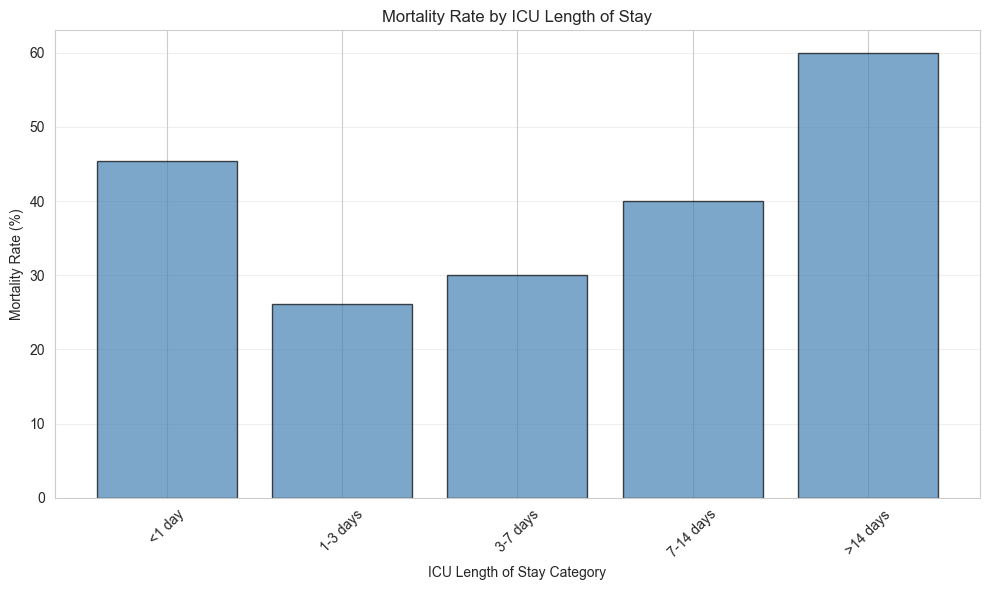

In [11]:
# Visualize
plt.figure(figsize=(10, 6))
plt.bar(range(len(mortality_by_los)), mortality_by_los['rate'], 
        edgecolor='black', alpha=0.7, color='steelblue')
plt.xticks(range(len(mortality_by_los)), mortality_by_los.index, rotation=45)
plt.ylabel('Mortality Rate (%)')
plt.xlabel('ICU Length of Stay Category')
plt.title('Mortality Rate by ICU Length of Stay')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Reward Function Design Options

In [12]:
print("="*80)
print("REWARD FUNCTION DESIGN OPTIONS")
print("="*80)
print("""
Based on outcome analysis, here are reward function options for offline RL:

OPTION 1: Sparse Binary Reward (Simplest)
  - R = +1 if patient survives (at ICU discharge)
  - R = -1 if patient dies
  - R = 0 for all intermediate steps
  
  Pros: Simple, clear objective
  Cons: Credit assignment problem (which actions led to survival?)

OPTION 2: Time-Weighted Survival Reward
  - R_final = +10 if survived
  - R_final = -10 if died
  - R_step = -0.1 per hour (penalty for prolonged ICU stay)
  
  Pros: Encourages both survival AND shorter LOS
  Cons: May rush discharge inappropriately

OPTION 3: Dense Shaped Reward (Recommended)
  - R_survival = +10 if survived, -10 if died (final step only)
  - R_step = small intermediate rewards based on:
    * Vital stability (e.g., HR, BP in normal range: +0.1)
    * Lab improvement (e.g., lactate decreasing: +0.2)
  - R_penalty = -0.05 per hour to encourage discharge readiness
  
  Pros: Provides learning signal throughout episode
  Cons: Requires domain knowledge to design intermediate rewards

OPTION 4: SOFA Score-Based Reward (Clinical Standard)
  - Use Sequential Organ Failure Assessment (SOFA) score
  - R = -Δ(SOFA) (negative change in SOFA is good)
  - R_final = +10 if survived
  
  Pros: Clinically validated measure of severity
  Cons: Requires calculating SOFA from vitals/labs

RECOMMENDATION FOR INITIAL IMPLEMENTATION:
  Start with Option 1 (sparse binary) to establish baseline, then move to 
  Option 3 (dense shaped) for better learning.
  
  Example Implementation:
  ```python
  def compute_reward(step, is_final, survived, vitals):
      reward = 0.0
      
      if is_final:
          reward += 10.0 if survived else -10.0
      else:
          # Small step penalty to encourage efficiency
          reward -= 0.05
          
          # Vital stability bonus
          if 60 <= vitals['hr'] <= 100:
              reward += 0.05
          if 90 <= vitals['sbp'] <= 140:
              reward += 0.05
              
      return reward
  ```
""")
print("="*80)

REWARD FUNCTION DESIGN OPTIONS

Based on outcome analysis, here are reward function options for offline RL:

OPTION 1: Sparse Binary Reward (Simplest)
  - R = +1 if patient survives (at ICU discharge)
  - R = -1 if patient dies
  - R = 0 for all intermediate steps
  
  Pros: Simple, clear objective
  Cons: Credit assignment problem (which actions led to survival?)

OPTION 2: Time-Weighted Survival Reward
  - R_final = +10 if survived
  - R_final = -10 if died
  - R_step = -0.1 per hour (penalty for prolonged ICU stay)
  
  Pros: Encourages both survival AND shorter LOS
  Cons: May rush discharge inappropriately

OPTION 3: Dense Shaped Reward (Recommended)
  - R_survival = +10 if survived, -10 if died (final step only)
  - R_step = small intermediate rewards based on:
    * Vital stability (e.g., HR, BP in normal range: +0.1)
    * Lab improvement (e.g., lactate decreasing: +0.2)
  - R_penalty = -0.05 per hour to encourage discharge readiness
  
  Pros: Provides learning signal througho

## 8. Outcome Summary Statistics

In [13]:
# Create outcome summary table
outcome_summary = pd.DataFrame({
    'Metric': [
        'Total Episodes',
        'Hospital Deaths',
        'Hospital Mortality Rate',
        'ICU Deaths',
        'ICU Mortality Rate',
        'Median LOS (Survivors)',
        'Median LOS (Non-Survivors)',
        'Median Time to Death (hours)',
    ],
    'Value': [
        len(episodes),
        int(episodes['hospital_expire_flag'].sum()),
        f"{episodes['hospital_expire_flag'].mean()*100:.1f}%",
        int(episodes['icu_mortality'].sum()),
        f"{episodes['icu_mortality'].mean()*100:.1f}%",
        f"{survivors_los.median():.1f} days",
        f"{non_survivors_los.median():.1f} days",
        f"{died_patients['hours_to_death'].median():.1f}h" if len(died_patients) > 0 else 'N/A',
    ]
})

print("\n" + "="*60)
print("OUTCOME SUMMARY FOR RL REWARD DESIGN")
print("="*60)
print(outcome_summary.to_string(index=False))
print("="*60)


OUTCOME SUMMARY FOR RL REWARD DESIGN
                      Metric    Value
              Total Episodes      136
             Hospital Deaths       46
     Hospital Mortality Rate    33.8%
                  ICU Deaths       36
          ICU Mortality Rate    26.5%
      Median LOS (Survivors) 2.0 days
  Median LOS (Non-Survivors) 2.6 days
Median Time to Death (hours)   100.5h


## Key Insights

1. **Mortality Rate**: ~30% hospital mortality (typical for ICU)
2. **Class Imbalance**: Need to handle imbalanced outcomes in RL training
3. **LOS Variation**: Wide range (hours to weeks); affects episode length
4. **Reward Signal**: Sparse (only at end) vs dense (intermediate rewards)
5. **Credit Assignment**: Challenge of attributing survival to specific actions

## Next Steps
- Implement reward function module (start with sparse, add dense later)
- Create episode termination logic (death, discharge, max horizon)
- Design reward shaping based on clinical indicators
- Consider adding penalty for aggressive treatments (conservative RL)